In [265]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations
#from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [266]:
import importlib
# Import Weyl specific classes 
import cloelib.cosmology.Weyl_perturbations as wp

importlib.reload(wp)

from cloelib.cosmology.Weyl_perturbations import Weyl_Perturbations

import cloelib.observables.photo_Weyl as pw

# reload module
importlib.reload(pw)

# re-bind updated classes
PositionsTracer_Weyl_GC = pw.PositionsTracer_Weyl_GC
PositionsTracer_Weyl_GGL = pw.PositionsTracer_Weyl_GGL

In [267]:
import Cells_calculation_Weylproject 

importlib.reload(Cells_calculation_Weylproject)

Cells_calculation = Cells_calculation_Weylproject.Cells_calculation
Cells_calculation_Weyl = Cells_calculation_Weylproject.Cells_calculation_Weyl

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [268]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545,
                            N_mnu = 1)
#linear_perturbations_CAMB = CAMBLinearPerturbations(background=background, redshifts=zs)
#linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
#nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

In [301]:
#class_background = CLASSBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, 
#                           ns = 0.96, As = 2e-9, mnu = 0.06, gamma_MG = 0.545, N_mnu = 1)
class_background = CLASSBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, 
                            ns = 0.96, As = 2e-9, mnu = 0.00, gamma_MG = 0.545, N_mnu = 0)
linear_perturbations_CLASS = CLASSLinearPerturbations(background=class_background, redshifts=zs)

z_ini = 3
linear_perturbations_CLASS_Weyl = CLASSLinearPerturbations(background=class_background, redshifts=np.array([z_ini]))
# !! Does not work anymore because in the CAMBLinearPerturbations class, z is now enforced to contain 0 !!!

nonlinear_perturbations_CLASS = CLASSNonLinearPerturbations(background=class_background, redshifts=zs, nonlinear_model = 'Halofit')
nonlinear_perturbations_CLASS_Weyl = CLASSNonLinearPerturbations(background=class_background, redshifts=np.array([z_ini]),
                                                                 nonlinear_model = 'Halofit')
# nonlinear_perturbations_CLASS_Weyl.z has to contain z_ini to make sure that the growth factor can be calculated at z_ini

## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [302]:
# Execute this cell to download the data
data_downloaded = True #Set to False if you have not downloaded it yet

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [303]:
# Read the data using euclidlib v2025.w
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')
cls_example = el.photo.angular_power_spectra('cls_example.fits')
mixmats_example = el.photo.mixing_matrices('mixmats_example.fits')

#If you're using the newer 2026 euclidlib version
#z_nz, nz_example = el.phz.redshift_distributions('nz_example.fits')
#cls_example = el.le3.pk_wl.angular_power_spectra('cls_example.fits')
#mixmats_example = el.le3.pk_wl.mixing_matrices('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

In [304]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
# Note: dndz_pos_norm and 
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

In [305]:
# Compute effective redshifts
z_effs = []
for key in dndz_pos_norm.keys():
    n = dndz_pos_norm[key]
    dz = np.gradient(z_nz)
    z_eff = np.sum(z_nz * n * dz) / np.sum(n * dz)
    z_effs.append(z_eff)

z_effs = np.array(z_effs)

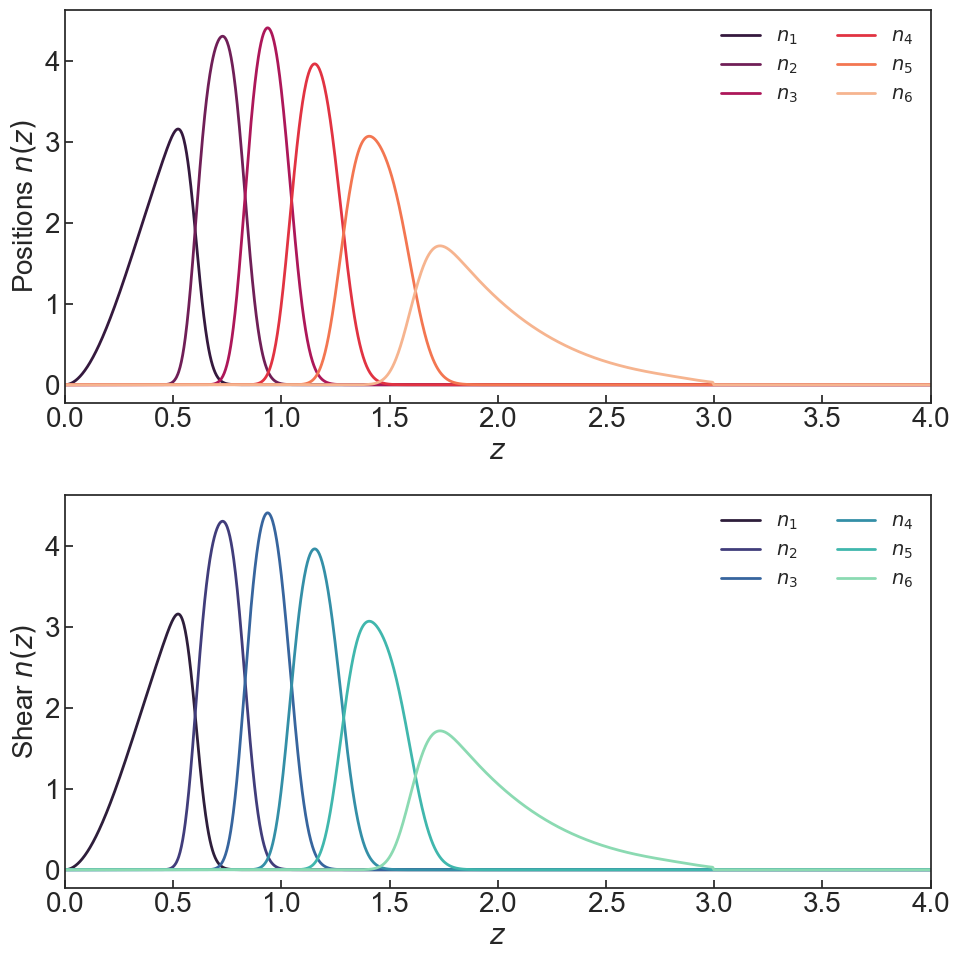

In [306]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## Observables: Different versions of shear and positions tracers with window functions

### Observables: shear and position tracers (standard )

We compute tracers (window functions) for both shear and galaxy positions observations, to be later combined in the computation of the summary statistics.

In [307]:
Cells_standard = Cells_calculation(linear_perturbations_CLASS, my_dndz_pos_norm, my_dndz_she_norm, zs)
Cells_standard.calculate_Cells()

#### Plots window functions

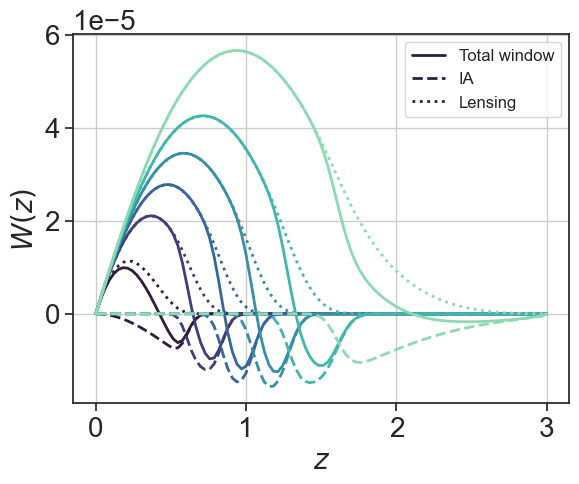

In [308]:
Cells_standard.plot_windows_she()

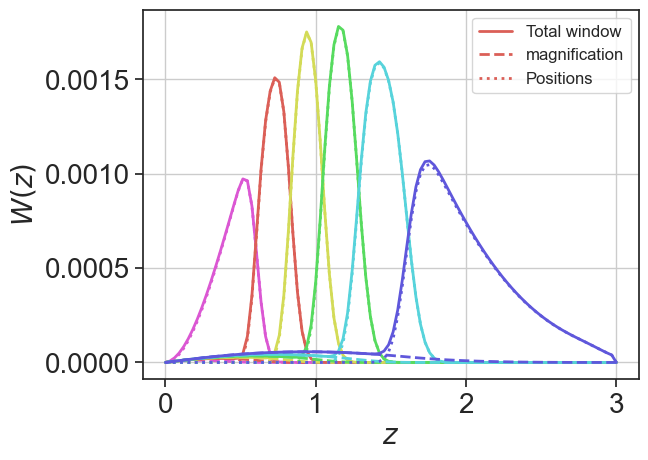

In [309]:
Cells_standard.plot_windows_pos()

#### Plots Cells

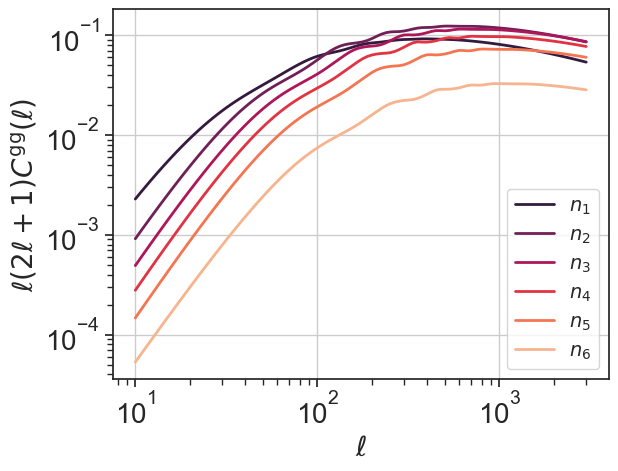

In [310]:
Cells_standard.plot_cells_GC()

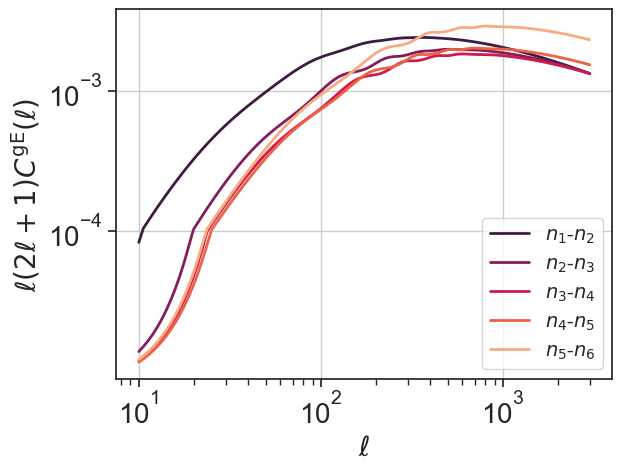

In [311]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_standard.plot_cells_GGL(ij_list)

### Observables: shear and position tracers using non-linear perturbations 

We compute tracers (window functions) for both shear and galaxy positions observations using non-linear CLASS perturbations, to be later combined in the computation of the summary statistics.

In [312]:
Cells_standard_nonlinear = Cells_calculation(nonlinear_perturbations_CLASS, my_dndz_pos_norm, my_dndz_she_norm, zs)
Cells_standard_nonlinear.calculate_Cells()

#### Plots window functions

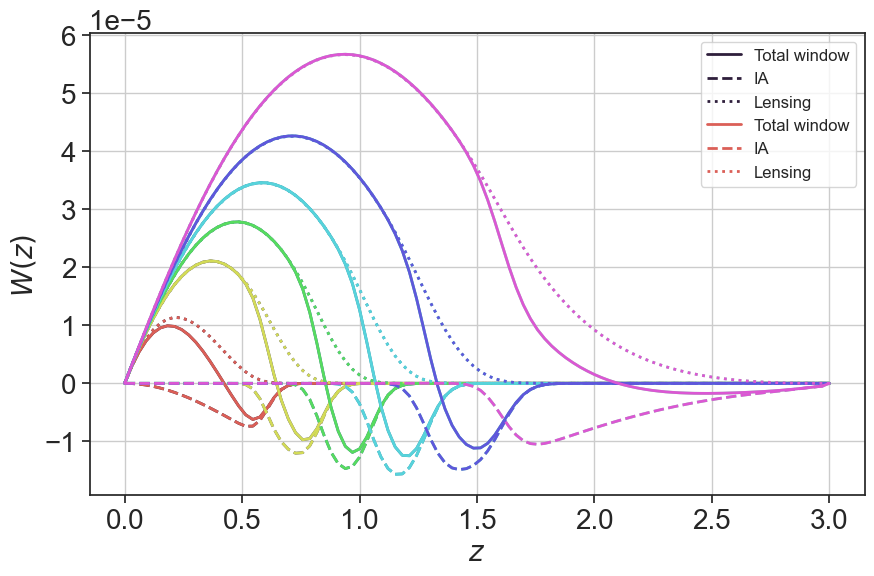

In [313]:
plt.figure(figsize=(10, 6))
Cells_standard.plot_windows_she()
Cells_standard_nonlinear.plot_windows_she(color_palette = 'hls')

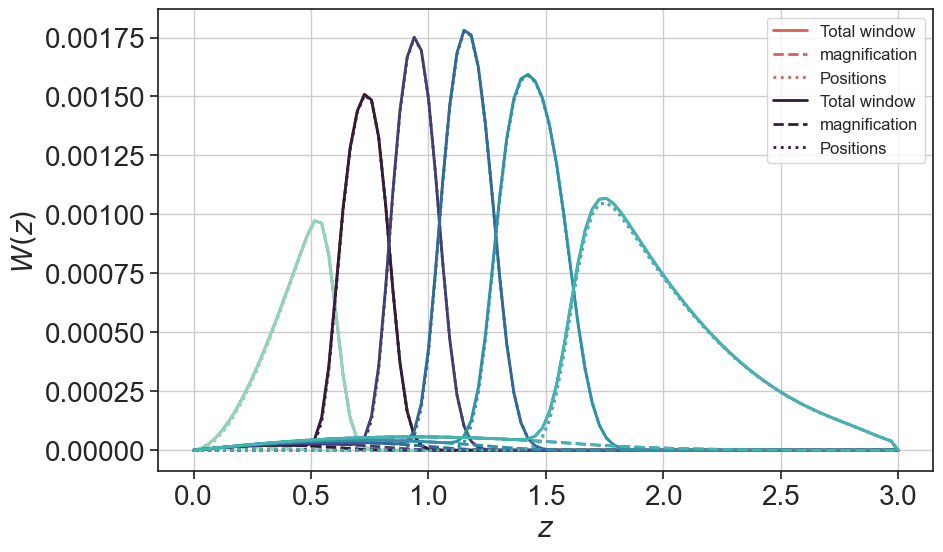

In [314]:
plt.figure(figsize=(10, 6))
Cells_standard.plot_windows_pos()
Cells_standard_nonlinear.plot_windows_pos(color_palette = 'mako')

#### Plots Cells

### Observables: Weyl implementation of position tracers

In [315]:
Cells_Weyl = Cells_calculation_Weyl(linear_perturbations_CLASS_Weyl, my_dndz_pos_norm, my_dndz_she_norm, zs, use_Weyl_perturbations = False)
Cells_Weyl.calculate_Cells()

#### Plots window functions

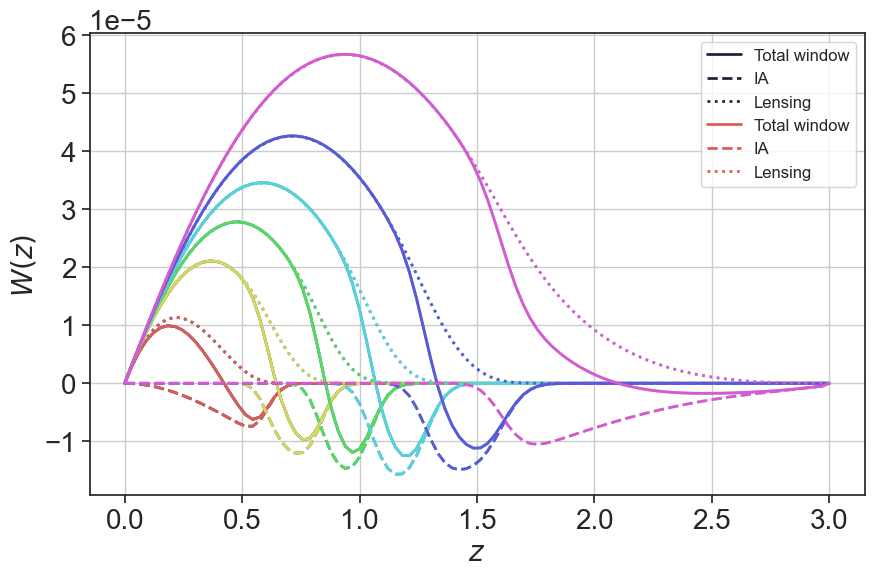

In [316]:
plt.figure(figsize=(10, 6))
Cells_Weyl.plot_windows_she()
Cells_standard.plot_windows_she(color_palette = 'hls')

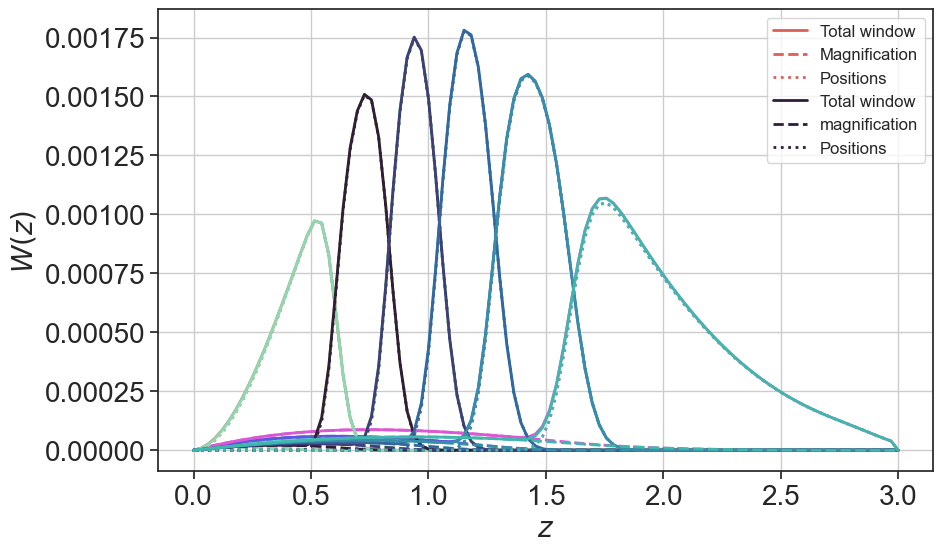

In [317]:
plt.figure(figsize=(10, 6))
Cells_Weyl.plot_windows_pos(pos_type = 'GC')
#Cells_Weyl.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

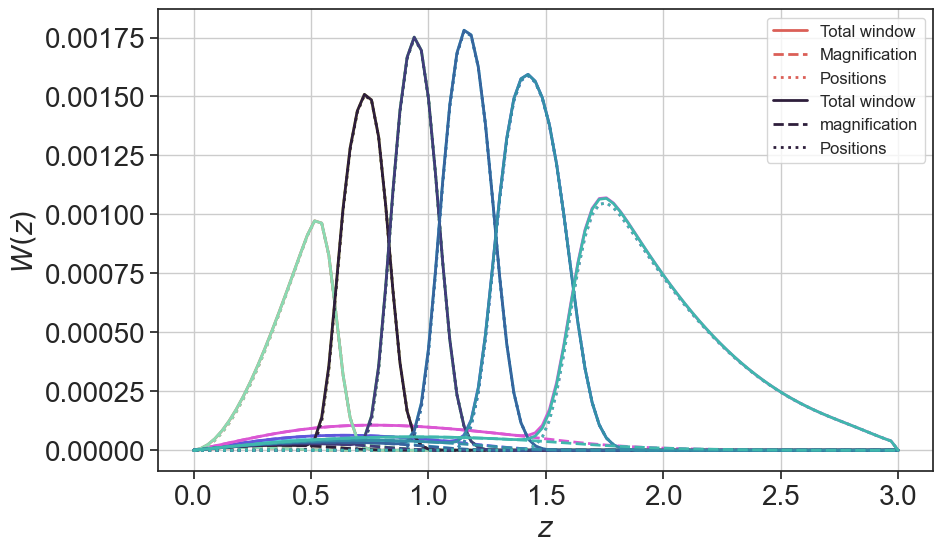

In [318]:
plt.figure(figsize=(10, 6))
#Cells_Weyl.plot_windows_pos(pos_type = 'GC')
Cells_Weyl.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

#### Plots Cells

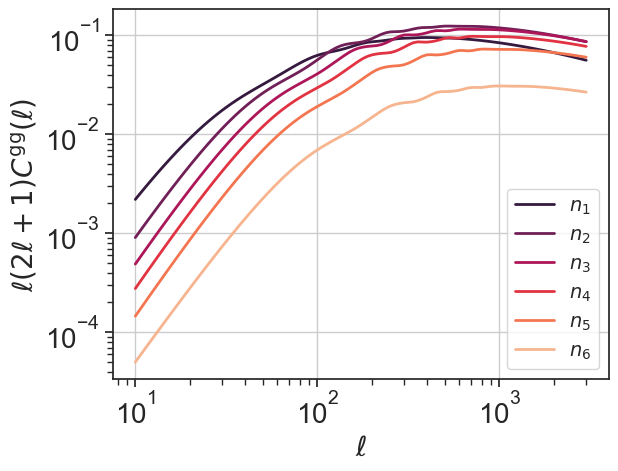

In [319]:
Cells_Weyl.plot_cells_GC()
#Cells_standard.plot_cells_GC(color_palette = 'mako')

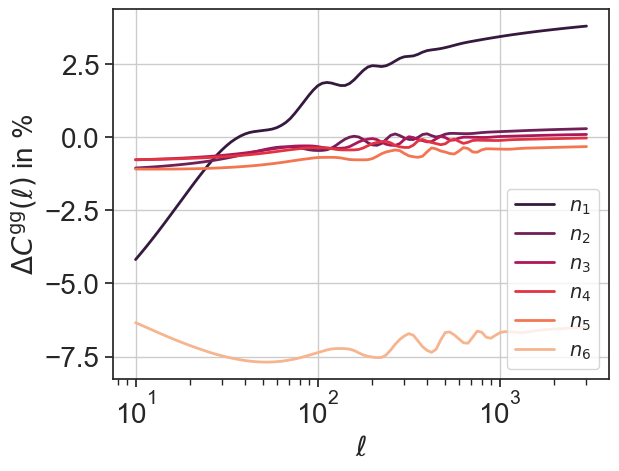

In [320]:
Cells_Weyl.plot_cells_GC_compare(Cells_standard)

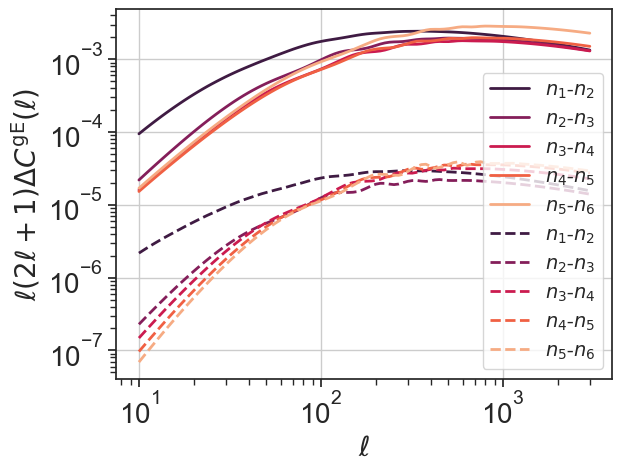

In [321]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl.plot_cells_GGL(ij_list)
Cells_Weyl.plot_cells_GGL_compare(Cells_standard, ij_list, in_percent = False, yscale = 'log')

### Observables: Weyl implementation of position tracers using Weyl_perturbations (with linear CLASS perturbations)

In [322]:
Cells_Weyl_useWeylpert = Cells_calculation_Weyl(linear_perturbations_CLASS_Weyl, my_dndz_pos_norm, my_dndz_she_norm, zs, use_Weyl_perturbations = True, z_ini=z_ini)
Cells_Weyl_useWeylpert.calculate_Cells()

#### Plots window functions

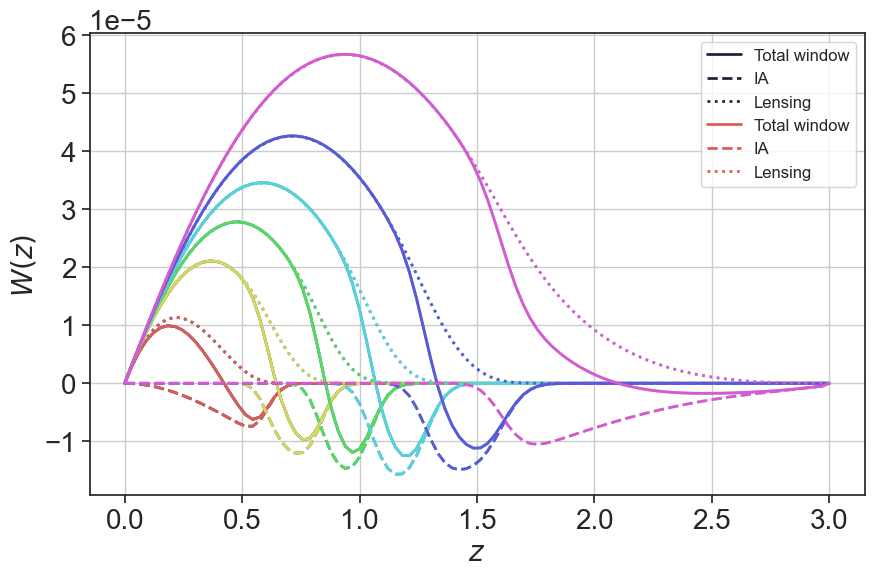

In [323]:
plt.figure(figsize=(10, 6))
Cells_Weyl_useWeylpert.plot_windows_she()
Cells_standard.plot_windows_she(color_palette = 'hls')

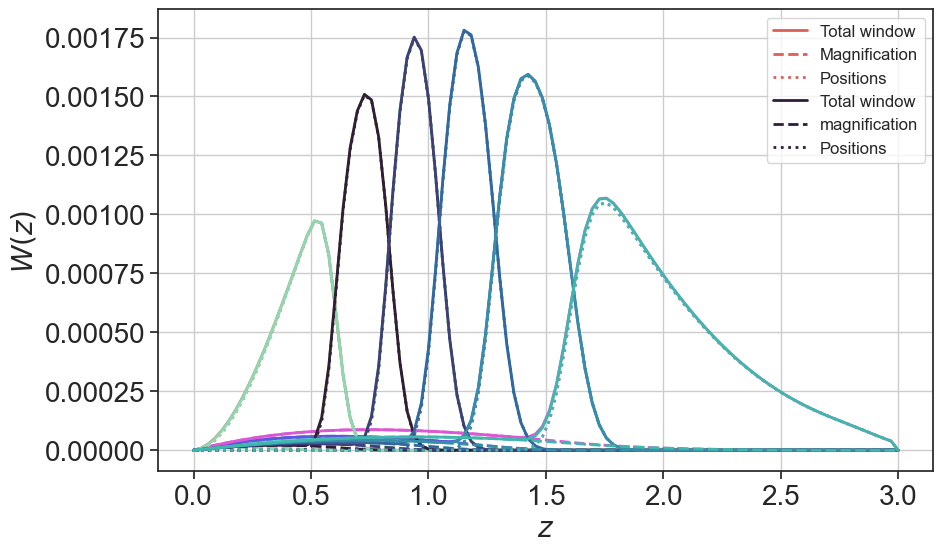

In [324]:
plt.figure(figsize=(10, 6))
Cells_Weyl_useWeylpert.plot_windows_pos(pos_type = 'GC')
#Cells_Weyl_useWeylpert.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

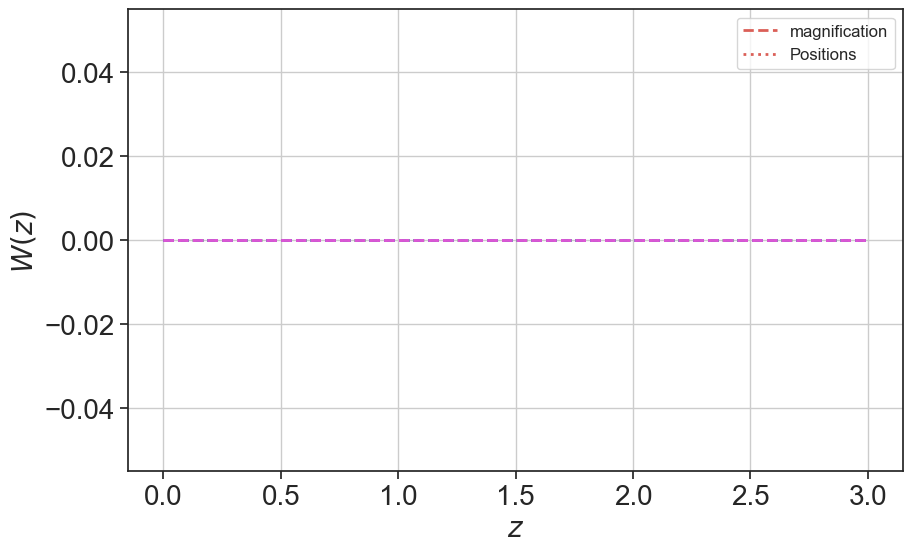

In [325]:
colors = sns.color_palette("hls", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):    
    # Plot the differences between the intrinsic alignment windows
    plt.plot(zs, 
             Cells_Weyl_useWeylpert.tracer_pos_GC.get_window_magnification(zs)[i, :]-Cells_Weyl.tracer_pos_GC.get_window_magnification(zs)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'magnification' if i == 1 else "")
    
    # Plot the differences between the position windows
    plt.plot(zs, 
             Cells_Weyl_useWeylpert.tracer_pos_GC.get_window_positions(zs)[i, :]-Cells_Weyl.tracer_pos_GC.get_window_positions(zs)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Positions' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

#### Plots Cells

In [326]:
Cells_Weyl_useWeylpert.perturbations.boost(np.array([1]), Cells_Weyl_useWeylpert.perturbations.k)

array([[1.        , 0.99998917, 0.99997502, 0.99995657, 0.99993261,
        0.99990172, 0.99986216, 0.99981205, 0.99974942, 0.9996726 ,
        0.99958051, 0.99947369, 0.99935467, 0.99922918, 0.99910564,
        0.99899416, 0.99890231, 0.99883292, 0.9987806 , 0.99873976,
        0.99870623, 0.99867945, 0.99865932, 0.99864431, 0.99863195,
        0.99862094, 0.99861802, 0.99862243, 0.99861858, 0.99860744,
        0.99859955, 0.99859611, 0.99859524, 0.99859426, 0.99859352,
        0.99859329, 0.99858779, 0.99857977, 0.99858224, 0.9985891 ,
        0.9985898 , 0.99858926, 0.99858559, 0.99858783, 0.99859154,
        0.99859022, 0.99857787, 0.99858691, 0.99858232, 0.99859015,
        0.99858008, 0.99857704, 0.99859168, 0.99859181, 0.99859156,
        0.99859179, 0.99858967, 0.99857667, 0.99857647, 0.99857801,
        0.99857728, 0.99857674, 0.99857602, 0.99857695, 0.99857685,
        0.99858839, 0.99859363, 0.99859137, 0.99859084, 0.99859106,
        0.99858805, 0.99857813, 0.99856813, 0.99

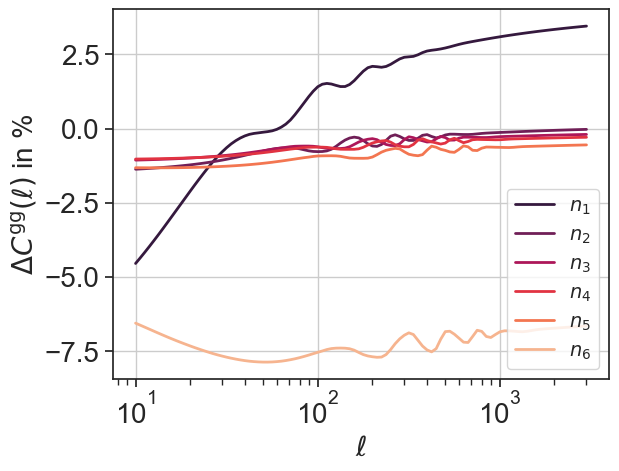

In [353]:
Cells_Weyl_useWeylpert.plot_cells_GC_compare(Cells_standard)

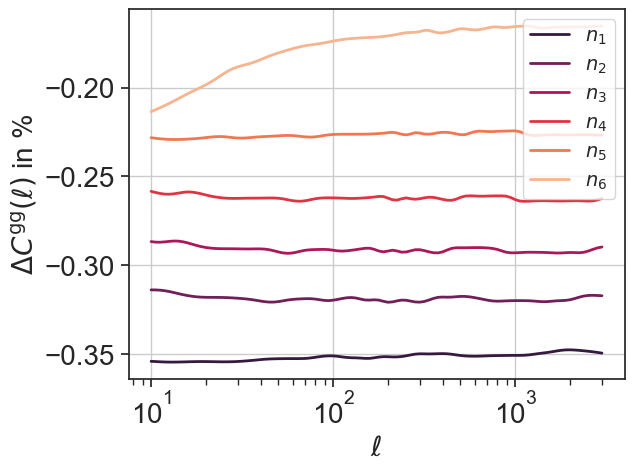

In [354]:
Cells_Weyl_useWeylpert.plot_cells_GC_compare(Cells_Weyl)

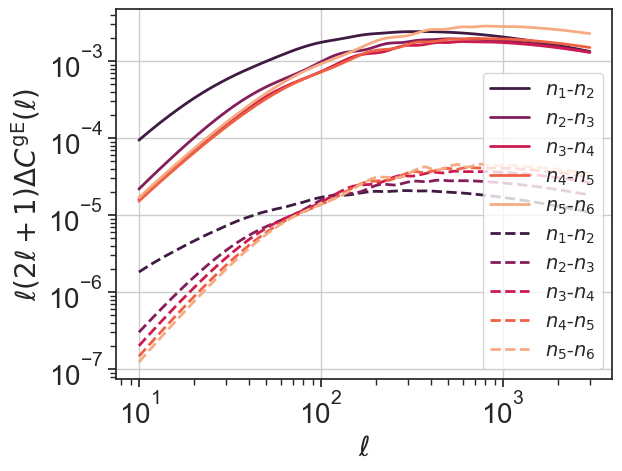

In [331]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_useWeylpert.plot_cells_GGL(ij_list)
Cells_Weyl_useWeylpert.plot_cells_GGL_compare(Cells_standard, ij_list, in_percent = False, yscale = 'log')

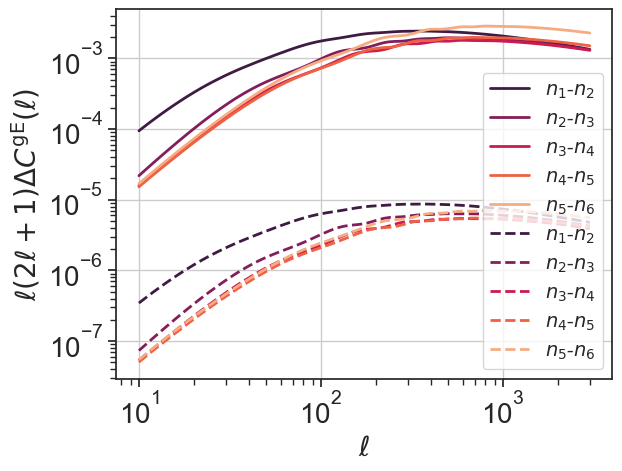

In [332]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_useWeylpert.plot_cells_GGL(ij_list)
Cells_Weyl_useWeylpert.plot_cells_GGL_compare(Cells_Weyl, ij_list, in_percent = False, yscale = 'log')

### Observables: Weyl implementation of position tracers using Weyl_perturbations (with linear CAMB perturbations)

### Observables: Weyl implementation of position tracers using Weyl_perturbations (with NON-LINEAR CLASS perturbations)

In [335]:
Cells_Weyl_nonlinear = Cells_calculation_Weyl(nonlinear_perturbations_CLASS_Weyl, my_dndz_pos_norm, my_dndz_she_norm, zs, 
                                              use_Weyl_perturbations = True, z_ini = z_ini)
Cells_Weyl_nonlinear.calculate_Cells()

#### Plots window functions

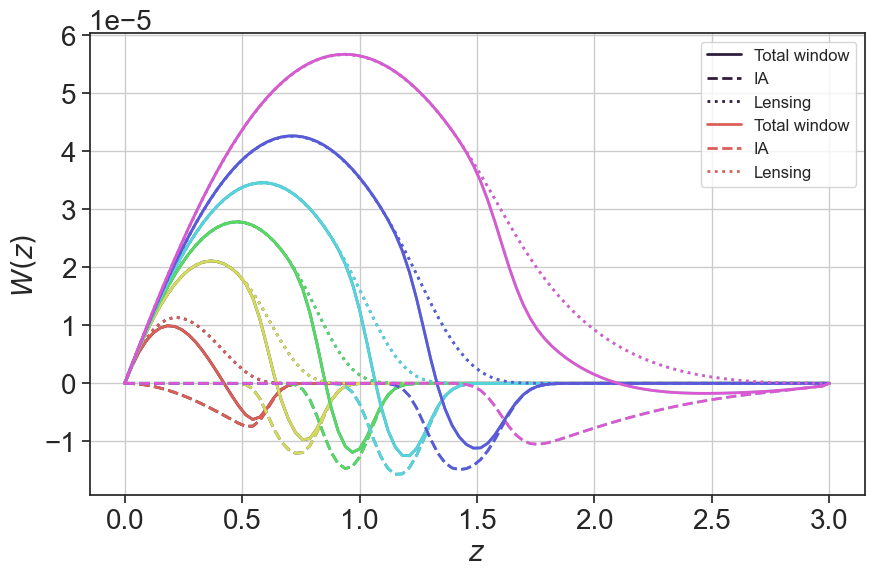

In [336]:
plt.figure(figsize=(10, 6))
Cells_Weyl_nonlinear.plot_windows_she()
Cells_standard.plot_windows_she(color_palette = 'hls')

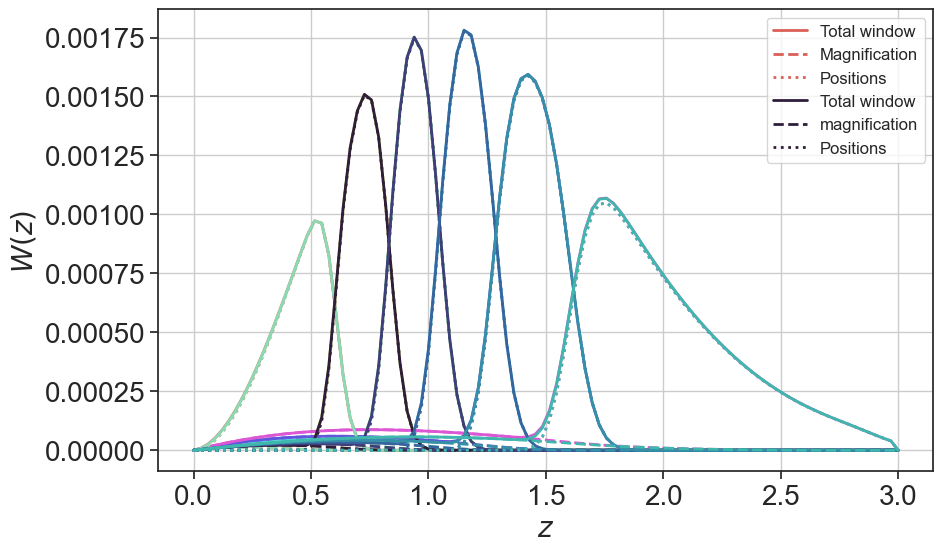

In [337]:
plt.figure(figsize=(10, 6))
Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GC')
#Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

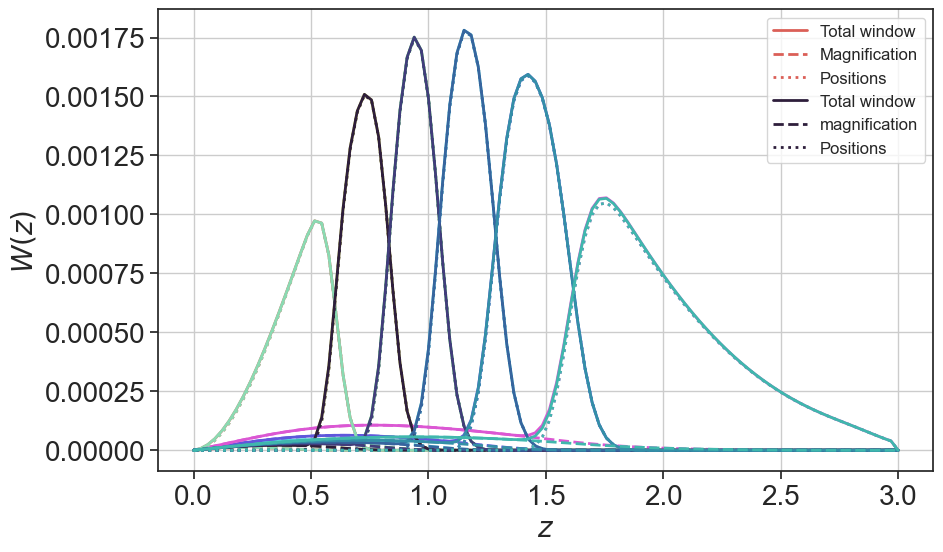

In [338]:
plt.figure(figsize=(10, 6))
#Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GC')
Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

#### Plots Cells

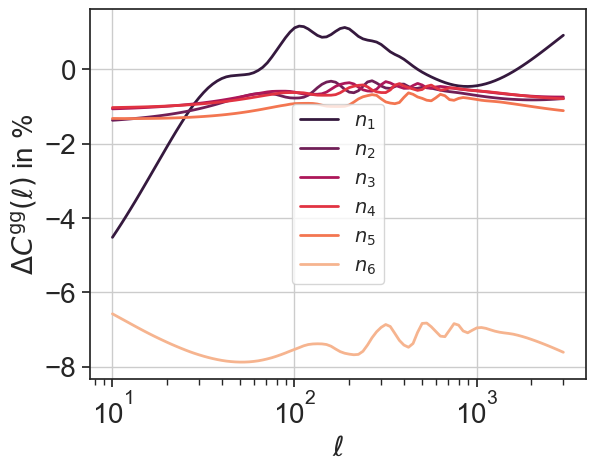

In [339]:
Cells_Weyl_nonlinear.plot_cells_GC_compare(Cells_standard_nonlinear)

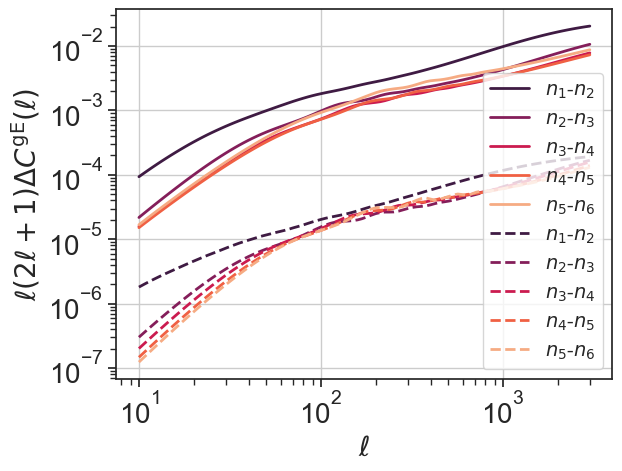

In [340]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_nonlinear.plot_cells_GGL(ij_list)
Cells_Weyl_nonlinear.plot_cells_GGL_compare(Cells_standard_nonlinear, ij_list, in_percent = False, yscale = 'log')

## Test: $C_\ell$ with sharpened redshift distribution

We want to check what happens if we sharpen the redshift distribution: Do the Cells for standard and Weyl implementation align better?

In [341]:
def renormalize(dndz, zs):
    dz = np.gradient(zs)
    # dndz shape: (nbins, nz)
    norms = np.sum(dndz * dz[None, :], axis=1)  # shape (nbins,)
    # avoid divide-by-zero
    norms[norms == 0] = 1.0
    return dndz / norms[:, None]

# compute effective z and RMS sigma of each bin (using current sampling zs)
def compute_z_eff_and_sigma(dndz, zs):
    dz = np.gradient(zs)
    # dndz shape: (nbins, nz)
    z_mean = np.sum(dndz * zs[None, :] * dz[None, :], axis=1) / np.sum(dndz * dz[None, :], axis=1)
    # variance = <(z - z_mean)^2>
    var = np.sum(dndz * (zs[None, :] - z_mean[:, None])**2 * dz[None, :], axis=1) / np.sum(dndz * dz[None, :], axis=1)
    sigma = np.sqrt(var)
    return z_mean, sigma

# 1) Sharpen (narrow & peak more) by multiplicative Gaussian around z_eff
def sharpen_dndz_by_gaussian(my_dndz, zs, z_eff, sigma_current, sigma_scale=0.5):
    """
    my_dndz: array shape (nbins, nz) normalized per-bin
    zs: 1D redshift array corresponding to columns
    z_eff: array shape (nbins,) effective z for each bin
    sigma_current: array shape (nbins,) current RMS width for each bin
    sigma_scale: float <1 => narrower (sharpen); >1 => wider (but multiplicative method is mainly for sharpening)
    """
    nbins, nz = my_dndz.shape
    out = np.zeros_like(my_dndz)
    for i in range(nbins):
        sigma_new = sigma_current[i] * sigma_scale
        # if sigma_current is zero (pathological), choose a fallback small width
        if sigma_new == 0:
            sigma_new = 1e-3
        gauss = np.exp(-0.5 * ((zs - z_eff[i]) / sigma_new)**2)
        out[i, :] = my_dndz[i, :] * gauss
    out = renormalize(out, zs)
    return out

In [347]:
# Example workflow using your arrays:
# my_dndz_pos_norm has shape (nbins, nz) and is already normalized over z (using zs grid)
zs_grid = zs  # the 100-point zs you resampled to

# compute current z_eff and sigma for each bin (on the resampled grid)
z_eff_resampled, sigma_resampled = compute_z_eff_and_sigma(my_dndz_pos_norm , zs_grid)

# Sharpen: make them peak more (use sigma_scale < 1, like 0.4 or 0.6)
my_dndz_pos_sharper = sharpen_dndz_by_gaussian(my_dndz_pos_norm, zs_grid, z_eff_resampled, sigma_resampled, sigma_scale=0.05)
my_dndz_she_sharper = my_dndz_pos_sharper 

# check new effective redshifts and widths after transforms
z_eff_sharper, sigma_sharper = compute_z_eff_and_sigma(my_dndz_pos_sharper, zs_grid)

# Print a quick summary (example)
for i in range(my_dndz_pos_sharper.shape[0]):
    print(f"bin {i}: z_eff orig {z_eff_resampled[i]:.4f}, sigma orig {sigma_resampled[i]:.4f} "
          f"-> sharper sigma {sigma_sharper[i]:.4f}")

bin 0: z_eff orig 0.4371, sigma orig 0.1303 -> sharper sigma 0.0113
bin 1: z_eff orig 0.7260, sigma orig 0.0835 -> sharper sigma 0.0000
bin 2: z_eff orig 0.9424, sigma orig 0.0845 -> sharper sigma 0.0000
bin 3: z_eff orig 1.1640, sigma orig 0.0940 -> sharper sigma 0.0044
bin 4: z_eff orig 1.4370, sigma orig 0.1184 -> sharper sigma 0.0092
bin 5: z_eff orig 1.9631, sigma orig 0.3015 -> sharper sigma 0.0149


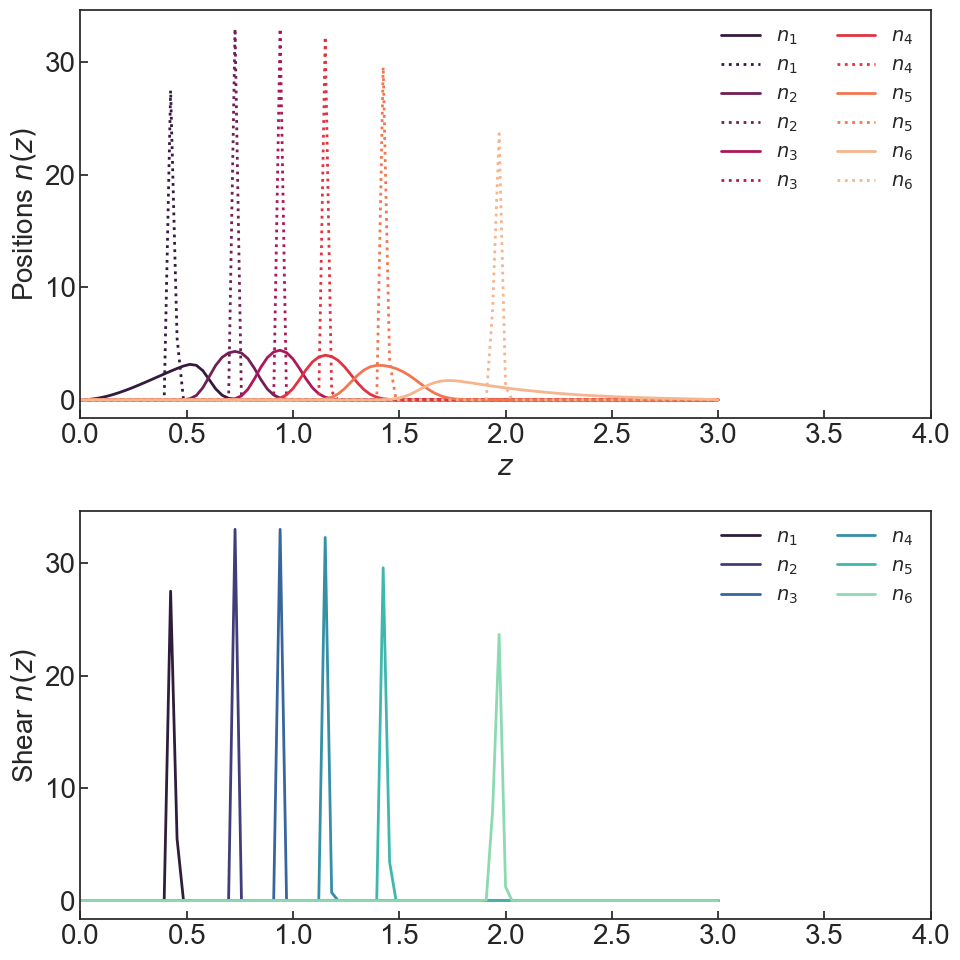

In [348]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i in range(6):
    color = sns.color_palette("rocket",6)[i]
    axs[0].plot(zs, my_dndz_pos_norm[i], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)
    axs[0].plot(zs, my_dndz_pos_sharper[i], linestyle=':', label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

#for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
#    axs[0].plot(z_nz, my_dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(my_dndz_she_norm)))):
    axs[1].plot(zs, my_dndz_she_sharper[j], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

#axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [349]:
Cells_standard_sharper = Cells_calculation(linear_perturbations_CLASS, my_dndz_pos_sharper, my_dndz_she_sharper, zs)
Cells_standard_sharper.calculate_Cells()
Cells_Weyl_sharper = Cells_calculation_Weyl(linear_perturbations_CLASS_Weyl, my_dndz_pos_sharper, my_dndz_she_sharper, zs, use_Weyl_perturbations = False)
Cells_Weyl_sharper.calculate_Cells()

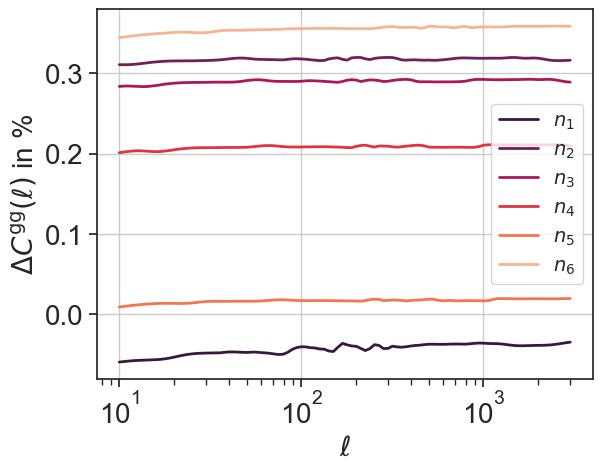

In [350]:
Cells_Weyl_sharper.plot_cells_GC_compare(Cells_standard_sharper)